##Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.



##Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

Data Description
The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee have any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* case_status: Flag indicating if the Visa was certified or denied

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To impute missing values
from sklearn.impute import SimpleImputer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/EasyVisa.csv")

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [4]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [5]:
df.shape

(25480, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [7]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000,25480.000,25480.000
mean,5667.043,1979.410,74455.815
std,22877.929,42.367,52815.942
min,-26.000,1800.000,2.137
25%,1022.000,1976.000,34015.480
50%,2109.000,1997.000,70308.210
75%,3504.000,2005.000,107735.513
max,602069.000,2016.000,319210.270


In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [9]:
print(df.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [10]:
df = df.drop('case_id', axis=1)

In [11]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'case_id' as it is an identifier
if 'case_id' in categorical_cols:
    categorical_cols.remove('case_id')

for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for continent:
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64


Value counts for education_of_employee:
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64


Value counts for has_job_experience:
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64


Value counts for requires_job_training:
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64


Value counts for region_of_employment:
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64


Value counts for unit_of_wage:
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64


Value counts for full_time_position:
full_time_position
Y    22773
N     2707
Name: count, dty

In [12]:
#Checking if no. of employees have negative values.
df['no_of_employees'].apply(
    lambda x: 'Negative' if x < 0 else 'Zero' if x == 0 else 'Positive'
).value_counts()


,count
no_of_employees,
Positive,25447
Negative,33


In [13]:
#Conisdering the absolute values of all negative values in the no. of employees.
df['no_of_employees'] = df['no_of_employees'].abs()

In [14]:
df['no_of_employees'].apply(
    lambda x: 'Negative' if x < 0 else 'Zero' if x == 0 else 'Positive'
).value_counts()

,count
no_of_employees,
Positive,25480


##EDA

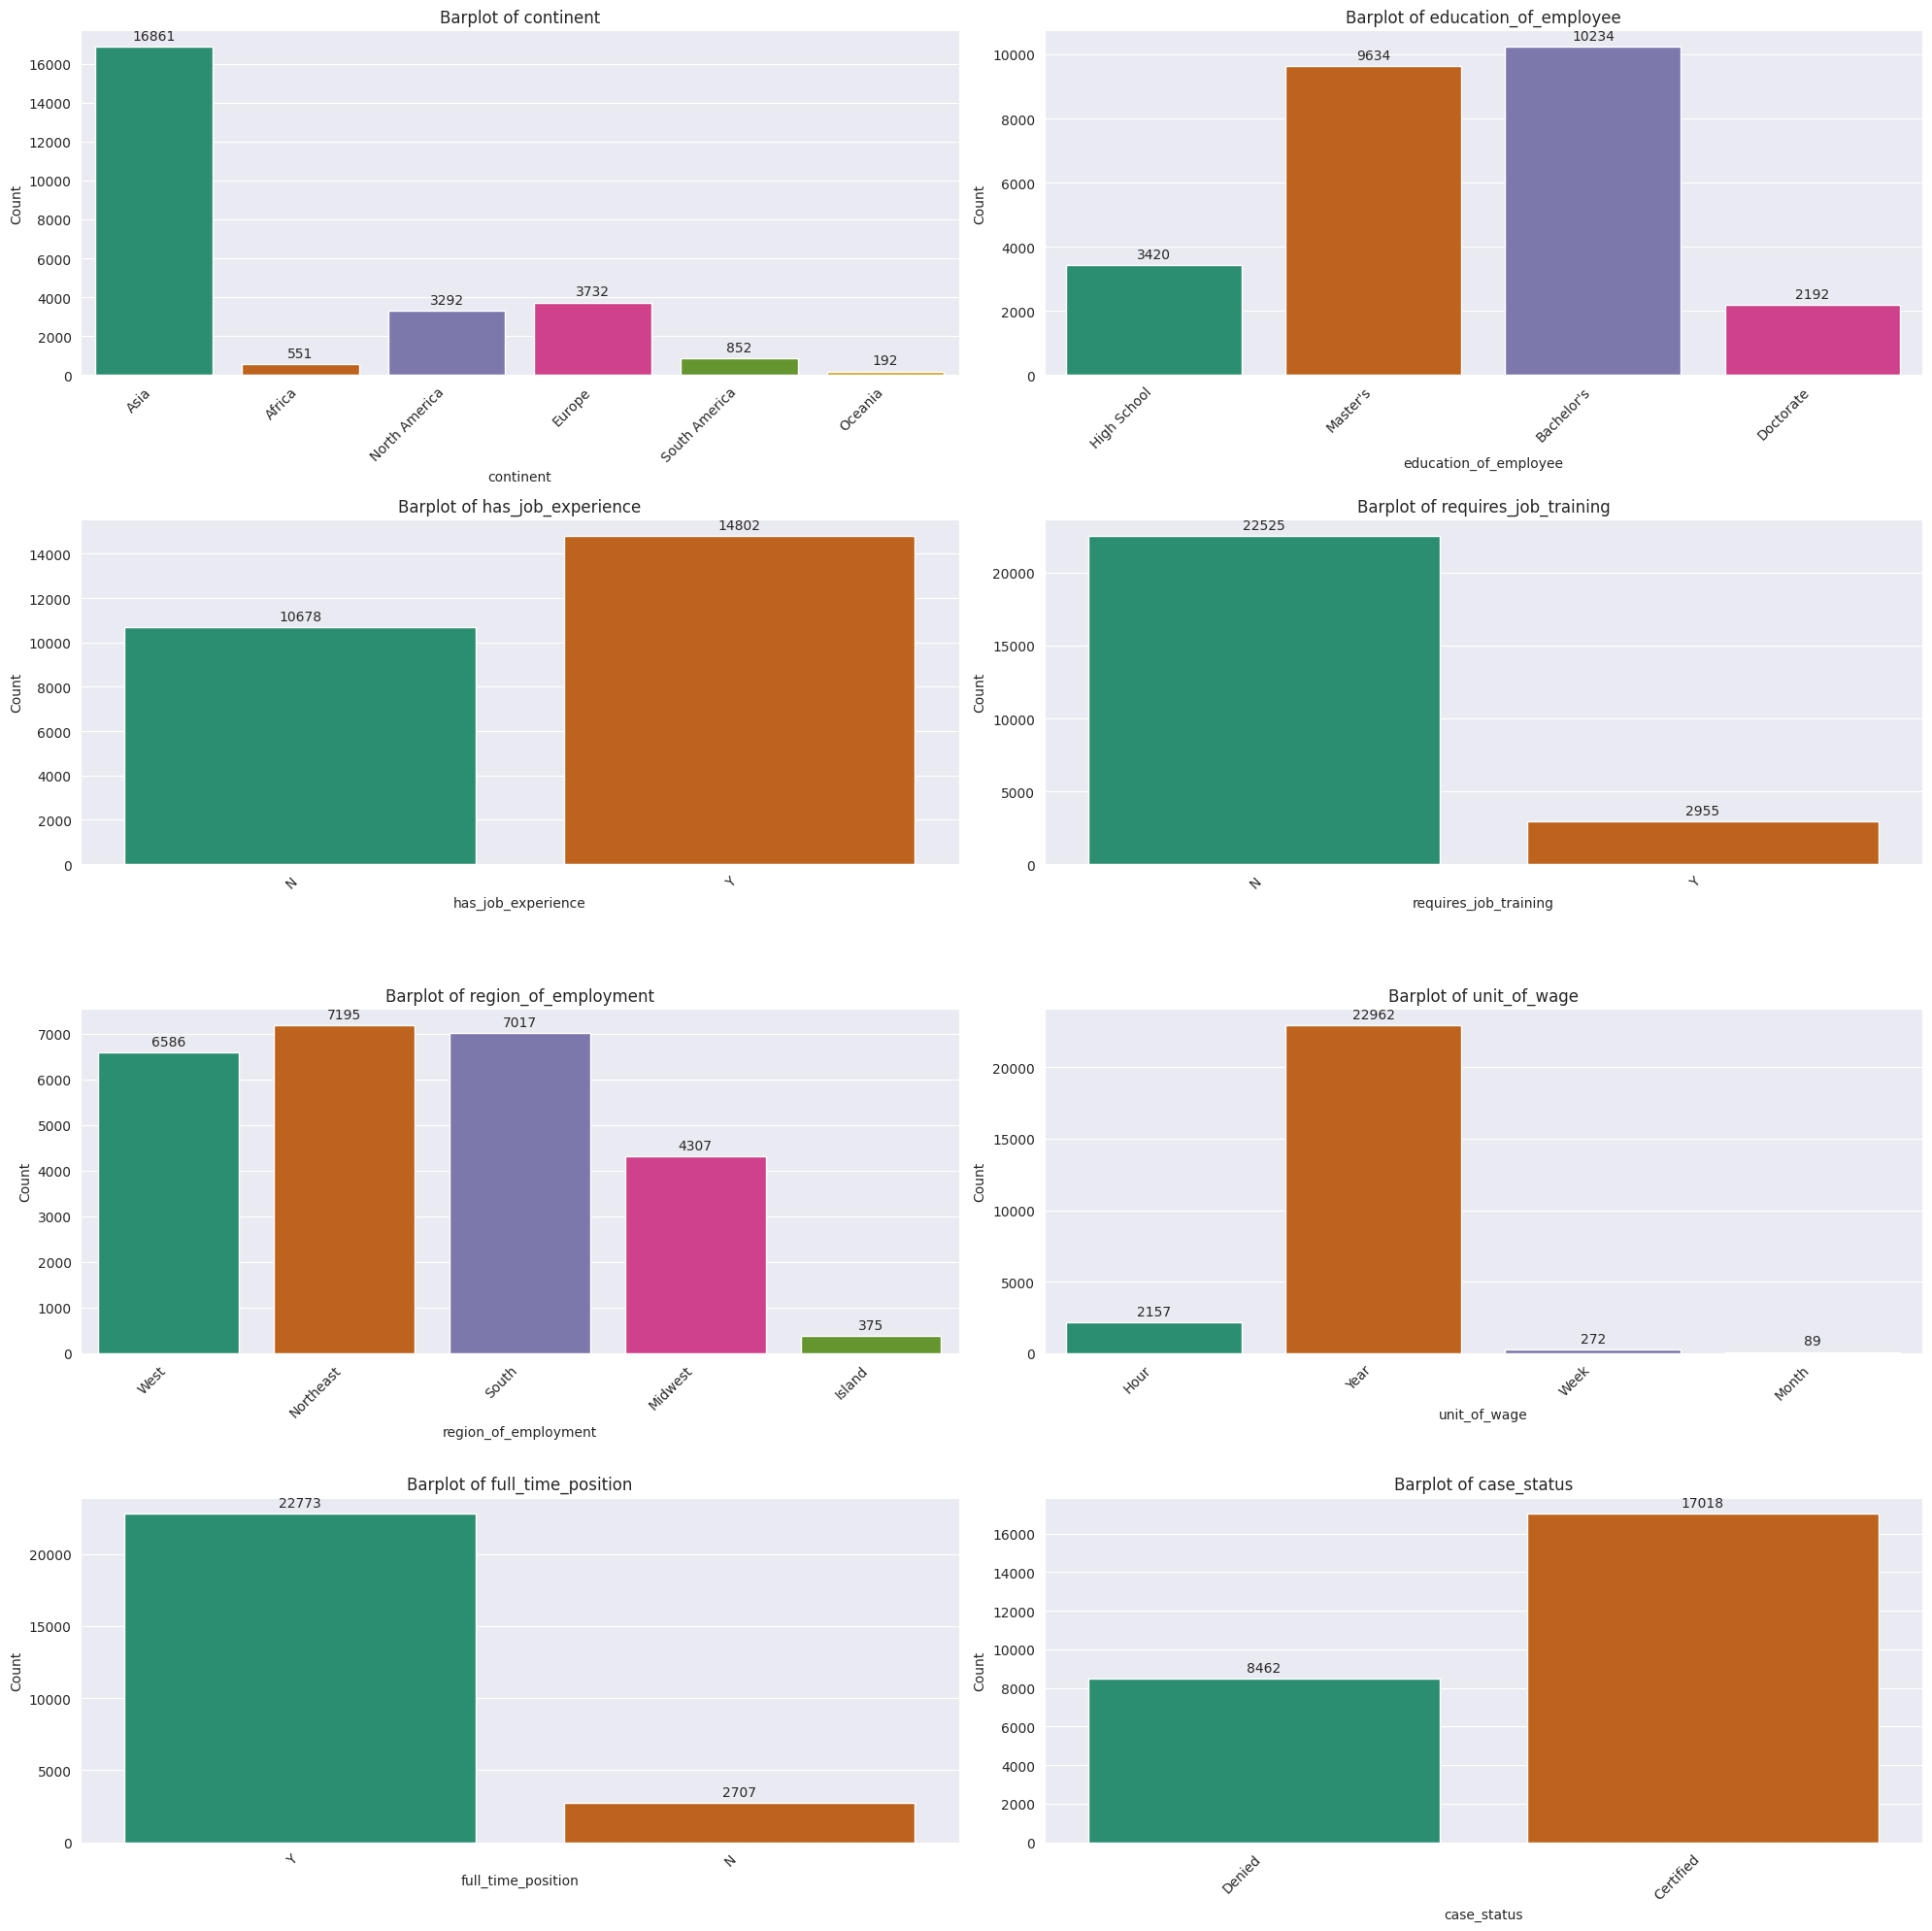

In [15]:
sns.set_style("darkgrid")

# Select only categorical columns (object or category dtype)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

cols_per_row = 2
total = len(cat_cols)
rows = int(np.ceil(total / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols_per_row, i)

    ax = sns.countplot(data=df, x=col, palette='Dark2') # Changed palette here
    plt.title(f"Barplot of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')

    # Add counts on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

#observation:
* Continent: The Asia continent has the largest representation of employees (~16,861), significantly more than North America (3,732) and Europe (3,470).
* Education: Most employees hold a Bachelor's degree (9,634) or a Master's degree (~10,234). High school diplomas (4,307) and doctorates (2,955) are less frequent.
* Job Experience: A large majority of employees appear to have job experience (Y category, 16,000) compared to those without (N category, 3,000-4,000). (The 'Y' count is approximately 14,802, the 'N' count is approximately 7,017).
* Job Training: The vast majority of employees do not require job training (N category, 22,525), while a small segment does (Y category, 2,955).
* Region of Employment: The Northeast (7,195) and South (7,017) regions of employment are dominant. The West (6,586), Midwest (4,307), South America (852), and Islands (375) have fewer employees.
* Unit of wage: The wages are majorly paid up on yearly basis(22962) and then followed by hourly basis (2157).
* Full-Time Position: A substantial majority of employees hold a full-time position (Y category, 22,773), compared to those who do not (N category, 2,707).
* Case Status: Nearly all employment cases appear to be Certified (17,018), with a much smaller number being Denied (8,462).

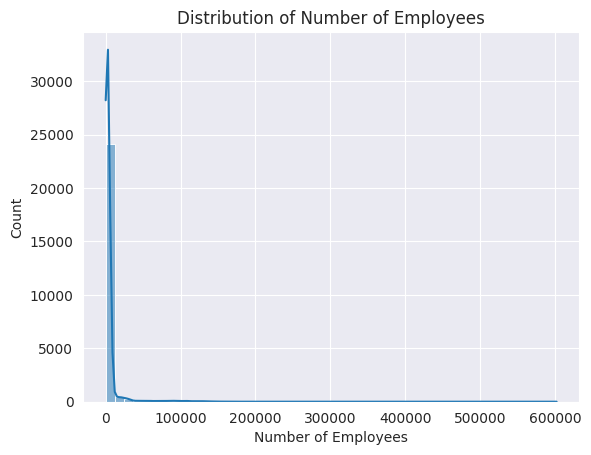

In [16]:
sns.histplot(df['no_of_employees'], bins=50, kde=True)
plt.title("Distribution of Number of Employees")
plt.xlabel("Number of Employees")
plt.show()


The data distribution is heavily right-skewed, indicating that the overwhelming majority of entities in this dataset have a very small number of employees (close to zero), while a few rare entities have a very high number of employees (up to 600,000).

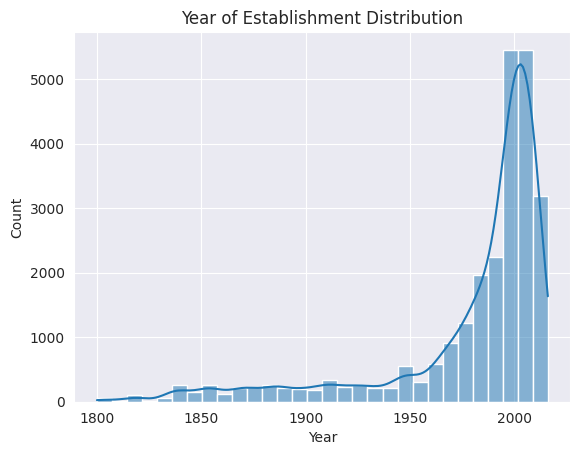

In [17]:
sns.histplot(df['yr_of_estab'], bins=30, kde=True)
plt.title("Year of Establishment Distribution")
plt.xlabel("Year")
plt.show()

The graph is the extreme right skew, indicating that the overwhelming majority of establishments in this dataset were founded around or after the year 2000, while very few date back to the 19th century.


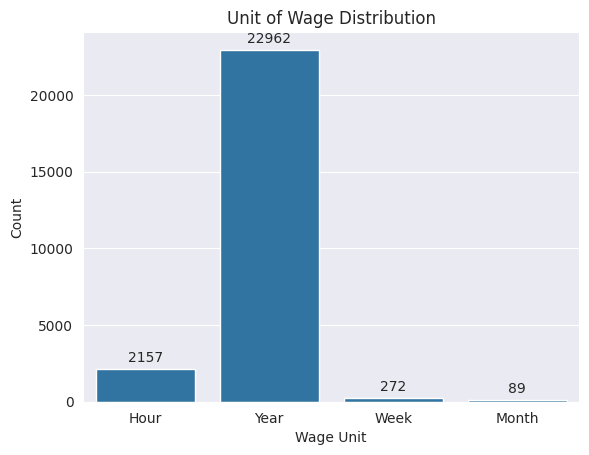

In [18]:
ax = sns.countplot(x='unit_of_wage', data=df)
plt.title("Unit of Wage Distribution")
plt.xlabel("Wage Unit")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.show()

The vast majority of wage records in this dataset use the "Year" (annual) unit as the basis for recording wages (22,962 entries), overwhelmingly dominating all other units like "Hour" (2,157), "Week" (272), and "Month" (89).

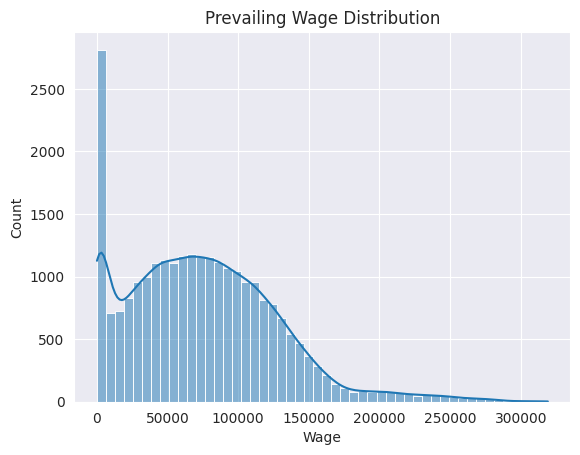

In [19]:
sns.histplot(df['prevailing_wage'], bins=50, kde=True)
plt.title("Prevailing Wage Distribution")
plt.xlabel("Wage")
plt.show()

The distribution is highly right-skewed, indicating that the overwhelming majority of workers receive wages on the lower end of the scale (below approximately (150,000)), while a very small number of individuals earn significantly higher wages, extending the tail to over (300,000). This is because of the different basis of wage payment.

#Bivariate Analysis:

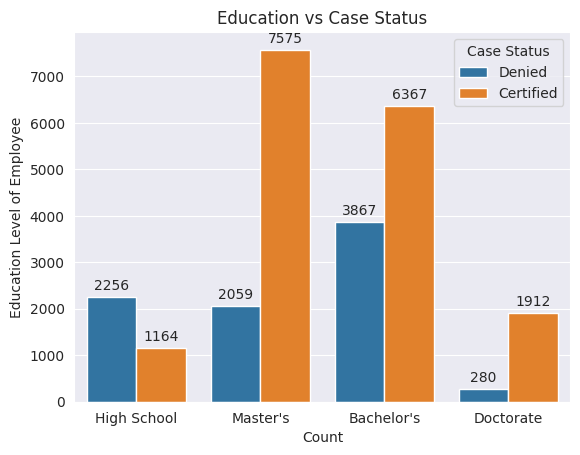

In [20]:
#education vs case status
ax = sns.countplot(x='education_of_employee', hue='case_status', data=df)
plt.title("Education vs Case Status")
plt.xlabel("Count")
plt.ylabel("Education Level of Employee")
plt.legend(title="Case Status")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.show()

For all education levels except High School, the Certified case status is significantly more frequent than the Denied status, with the largest gap seen among those with a Master's degree (7,575 Certified vs. 2,059 Denied). It shows that employee with Master's degree have got certified more compared to other education qualification.

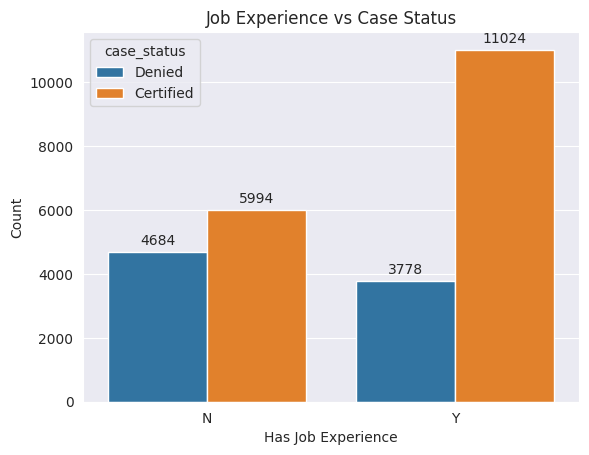

In [21]:
#Job experience vs case status
ax = sns.countplot(x='has_job_experience', hue='case_status', data=df)
plt.title("Job Experience vs Case Status")
plt.xlabel("Has Job Experience")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.show()

Having job experience ("Y") strongly increases the likelihood of a case being Certified (11,024 Certified vs. 3,778 Denied), demonstrating a clear positive correlation between experience and successful outcomes within this dataset.

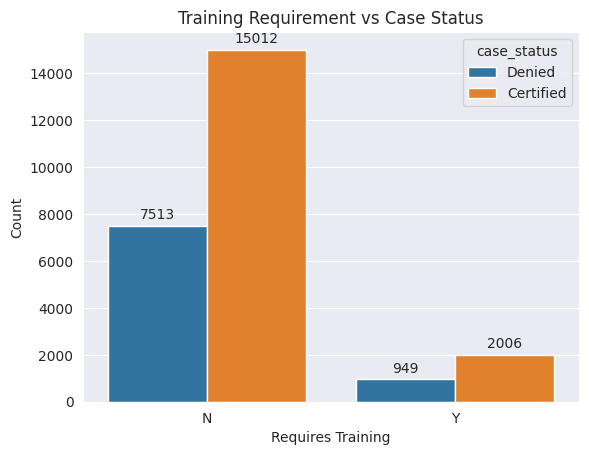

In [22]:
#Training requirement vs Case status
ax = sns.countplot(x='requires_job_training', hue='case_status', data=df)
plt.title("Training Requirement vs Case Status")
plt.xlabel("Requires Training")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.show()

The dataset primarily consists of cases where no training is required ("N"), accounting for a total of 22,525 entries, compared to only 2,955 entries where training is required ("Y").

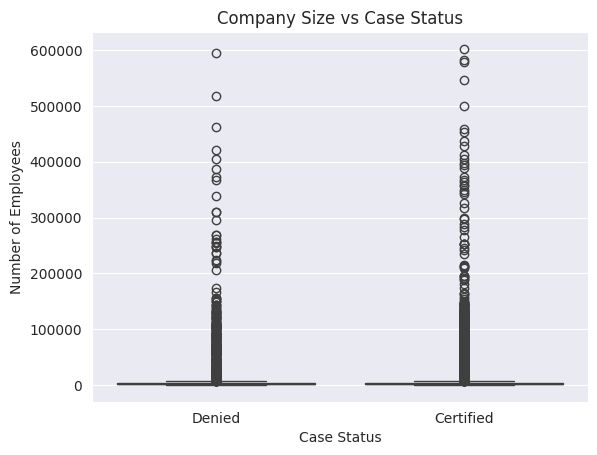

In [23]:
# No. of Employees vs Case status
sns.boxplot(x='case_status', y='no_of_employees', data=df)
plt.title("Company Size vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Number of Employees")
plt.show()

The median "Number of Employees" (the central line within the blue box) for companies with a Certified case status appears negligibly higher than the median for those with a Denied case status, although in both groups the median company size is extremely small (close to 0 employees).

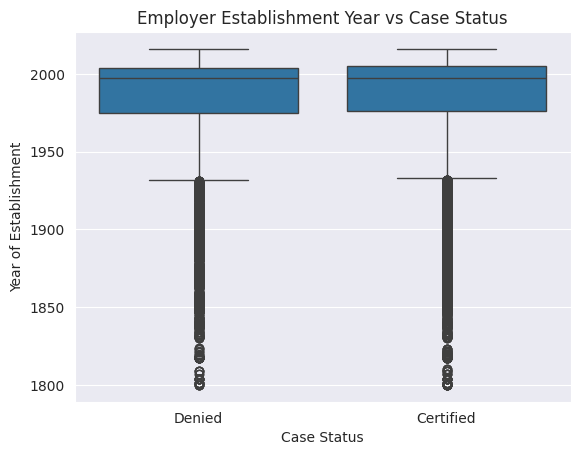

In [24]:
#Year of establishment vs Case Status
sns.boxplot(x='case_status', y='yr_of_estab', data=df)
plt.title("Employer Establishment Year vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Year of Establishment")
plt.show()

The distribution of employer establishment years for both Certified and Denied case statuses is virtually identical, indicating that the age of the employer has no discernible impact on the outcome of the case status within this dataset.

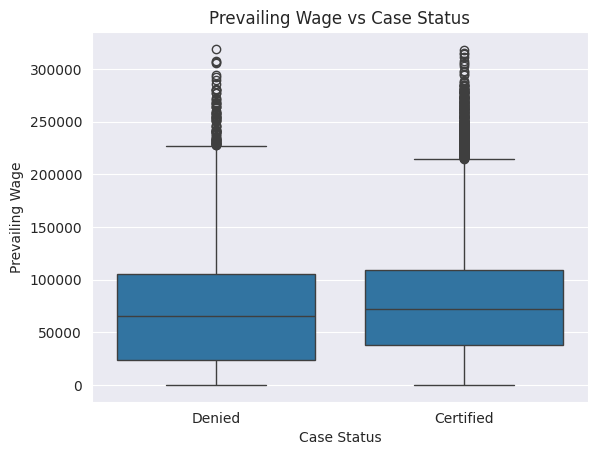

In [25]:
sns.boxplot(x='case_status', y='prevailing_wage', data=df)
plt.title("Prevailing Wage vs Case Status")
plt.xlabel("Case Status")
plt.ylabel("Prevailing Wage")
plt.show()


The median prevailing wage (the horizontal line inside the blue box) for cases that were Certified is nearly identical to the median wage for cases that were Denied, suggesting that the typical wage level itself is not a major determining factor in the case outcome.

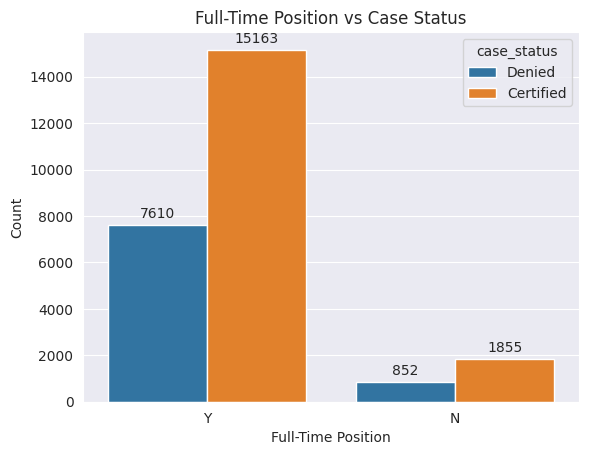

In [26]:
#Full time position vs Case status
ax = sns.countplot(x='full_time_position', hue='case_status', data=df)
plt.title("Full-Time Position vs Case Status")
plt.xlabel("Full-Time Position")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.show()


The vast majority of cases involve a full-time position ("Y"), and within that group, the number of Certified cases (15,163) is nearly double the number of Denied cases (7,610).

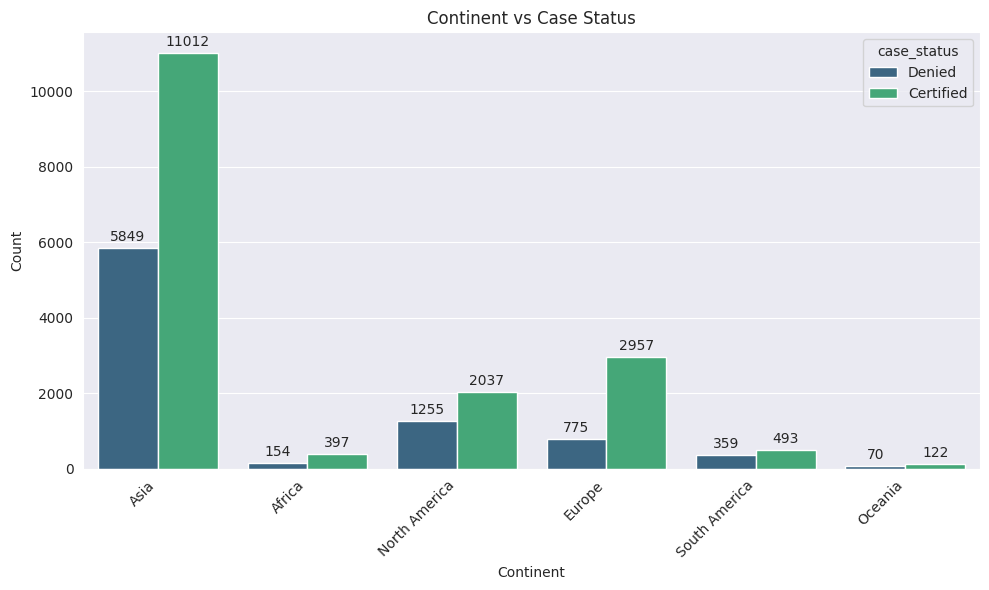

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='continent', hue='case_status', data=df, palette='viridis')
plt.title("Continent vs Case Status")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

Asia has by far the highest number of total cases compared to any other continent, and within Asia, the number of Certified cases (11,012) is nearly double the number of Denied cases (5,849).


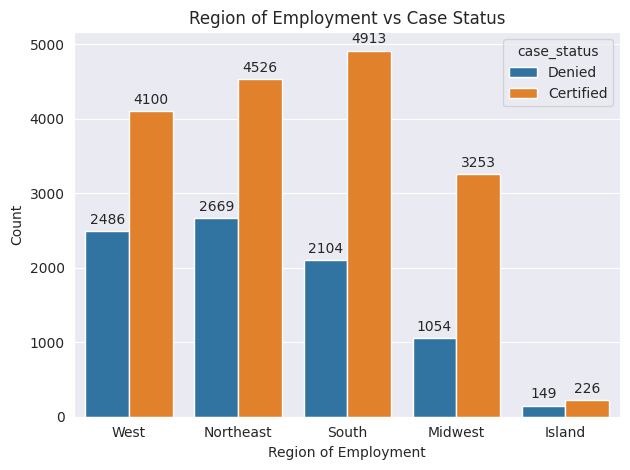

In [28]:
# Region of Employment vs Case status
ax = sns.countplot(x='region_of_employment', hue='case_status', data=df)
plt.title("Region of Employment vs Case Status")
plt.xlabel("Region of Employment")
plt.ylabel("Count")

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In every single region shown in this dataset (West, Northeast, South, Midwest, and Island), the number of Certified cases consistently and significantly outnumbers the number of Denied cases.


In [29]:
# Copy dataset
heatmap_df = df.copy()

# Encode binary categorical variables
binary_map = {'Y': 1, 'N': 0}
binary_cols = ['has_job_experience', 'requires_job_training', 'full_time_position']

for col in binary_cols:
    heatmap_df[col] = heatmap_df[col].map(binary_map)

# Encode target variable
heatmap_df['case_status'] = (heatmap_df['case_status'] == 'Certified').astype(int)

# Select numeric + binary columns
heatmap_cols = [
    'prevailing_wage',
    'no_of_employees',
    'yr_of_estab',
    'has_job_experience',
    'requires_job_training',
    'full_time_position',
    'case_status'
]

heatmap_df = heatmap_df[heatmap_cols]


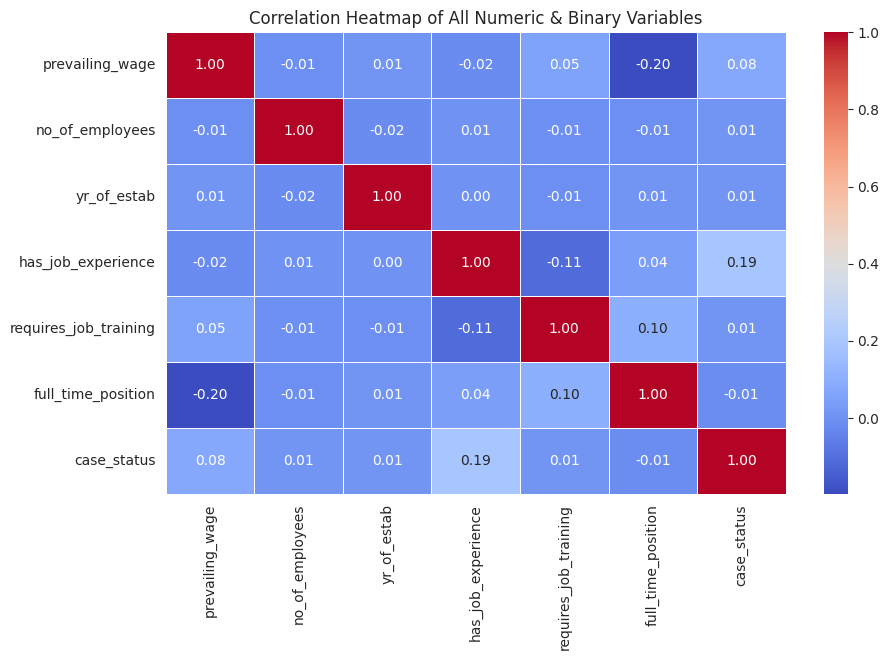

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Heatmap of All Numeric & Binary Variables")
plt.show()


All variables in this dataset exhibit very weak or negligible linear correlation with each other, as all correlation coefficients (absolute values) are (0.20), suggesting that changes in one variable have very little linear relationship with changes in any other variable.

#Data Preprocessing:

Converting the categorical variables accordingly:

In [31]:
#Binary conversion Yes and No
binary_cols = [
    'has_job_experience',
    'requires_job_training',
    'full_time_position'
]

df[binary_cols] = df[binary_cols].replace({'Y': 1, 'N': 0})

#Target Variable - Case Status
df['case_status'] = df['case_status'].map({
    'Certified': 1,
    'Denied': 0
})

In [32]:
education_order = {
    "Bachelor's" : 2,
    "Master's" : 3,
    "High School" : 1,
    "Doctorate" : 4
}

df['education_of_employee'] = df['education_of_employee'].map(education_order)

In [33]:
#One - Hot encoding
df = pd.get_dummies(
    df,
    columns=['continent', 'region_of_employment'],
    drop_first=True
)

In [34]:
# Convert all wages to yearly wage
def convert_to_yearly(row):
    if row['unit_of_wage'] == 'Hour':
        return row['prevailing_wage'] * 40 * 52  # 40 hours/week, 52 weeks
    elif row['unit_of_wage'] == 'Week':
        return row['prevailing_wage'] * 52       # 52 weeks/year
    elif row['unit_of_wage'] == 'Month':
        return row['prevailing_wage'] * 12       # 12 months/year
    else:  # Yearly
        return row['prevailing_wage']

df['prevailing_wage_yearly'] = df.apply(convert_to_yearly, axis=1)

# Drop original wage columns
df.drop(['prevailing_wage', 'unit_of_wage'], axis=1, inplace=True)

In [35]:
df.head()

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,full_time_position,case_status,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,prevailing_wage_yearly
0,1,0,0,14513,2007,1,0,True,False,False,False,False,False,False,False,True,1231782.032
1,3,1,0,2412,2002,1,1,True,False,False,False,False,False,True,False,False,83425.650
2,2,0,1,44444,2008,1,0,True,False,False,False,False,False,False,False,True,122996.860
3,2,0,0,98,1897,1,0,True,False,False,False,False,False,False,False,True,83434.030
4,3,1,0,1082,2005,1,1,False,False,False,False,False,False,False,True,False,149907.390


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   education_of_employee           25480 non-null  int64  
 1   has_job_experience              25480 non-null  int64  
 2   requires_job_training           25480 non-null  int64  
 3   no_of_employees                 25480 non-null  int64  
 4   yr_of_estab                     25480 non-null  int64  
 5   full_time_position              25480 non-null  int64  
 6   case_status                     25480 non-null  int64  
 7   continent_Asia                  25480 non-null  bool   
 8   continent_Europe                25480 non-null  bool   
 9   continent_North America         25480 non-null  bool   
 10  continent_Oceania               25480 non-null  bool   
 11  continent_South America         25480 non-null  bool   
 12  region_of_employment_Midwest    

Outliers Treatment:

In [37]:
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers)

outlier_cols = ['prevailing_wage_yearly', 'no_of_employees', 'yr_of_estab']
outlier_counts = {}

for col in outlier_cols:
    count = count_outliers(df, col)
    outlier_counts[col] = count

for col, count in outlier_counts.items():
    print(f"Number of outliers in '{col}': {count}")

Number of outliers in 'prevailing_wage_yearly': 2387
Number of outliers in 'no_of_employees': 1556
Number of outliers in 'yr_of_estab': 3260


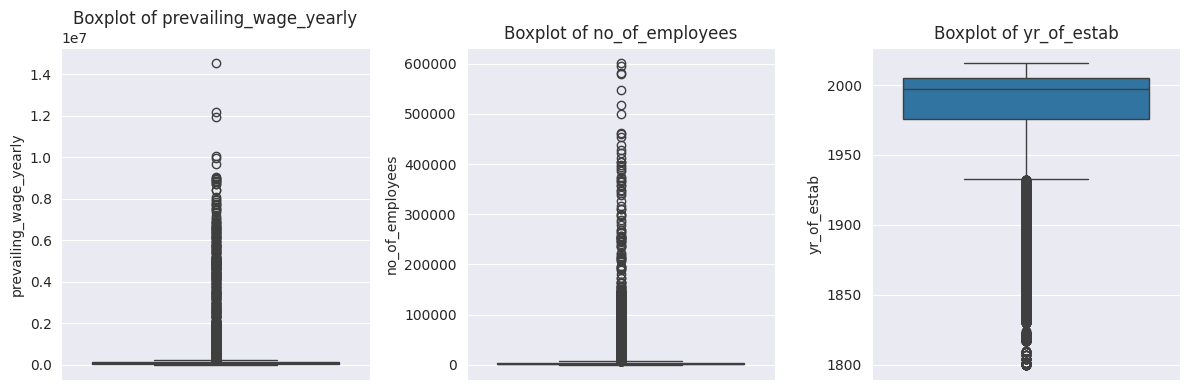

In [38]:
num_cols = ['prevailing_wage_yearly', 'no_of_employees', 'yr_of_estab']


plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


All the variables seen to have outliers and the outliers seem to be genuine so considered not to be treated.

Split the data into X and y


In [39]:
x = df.drop('case_status', axis=1)
y = df['case_status']

In [40]:
#Splitting data into training, validation and test set:

#First we split data into 2 parts, temporary and test
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify = y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=0.2, random_state=42, stratify = y_temp
)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of x_test: {x_test.shape}")

Shape of x_train: (16307, 16)
Shape of x_val: (4077, 16)
Shape of x_test: (5096, 16)


In [41]:
#Checking class balance for whole data, train set, validation set and test set

print("target value ratio in y")
print(y.value_counts(1))
print("*" * 40)
print("target value ratio in y_train")
print(y_train.value_counts(1))
print("*" * 40)
print("target value ratio in y_val")
print(y_val.value_counts(1))
print("*" * 40)
print("target value ratio in y_test")
print(y_test.value_counts(1))

target value ratio in y
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
****************************************
target value ratio in y_train
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
****************************************
target value ratio in y_val
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
****************************************
target value ratio in y_test
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64


In [42]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [43]:
def get_metrics_score(model, x_train, x_val, y_train, y_val, print_output=True):
    """
    Calculates Accuracy, Recall, Precision, and F1-score for a given model
    on both training and validation sets, and returns these metrics.

    Args:
        model: The trained machine learning model.
        x_train: Training features.
        x_val: Validation features (or test features).
        y_train: True labels for the training set.
        y_val: True labels for the validation set (or test labels).
        print_output (bool): If True, prints the metrics. Defaults to True.
    Returns:
        Tuple: (train_accuracy, val_accuracy, train_recall, val_recall,
                train_precision, val_precision, train_f1, val_f1)
    """
    # For Training Set
    y_train_pred = model.predict(x_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # For Validation Set
    y_val_pred = model.predict(x_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    if print_output:
        print("Train Metrics:")
        print(f"Accuracy: {train_accuracy:.4f}")
        print(f"Recall: {train_recall:.4f}")
        print(f"Precision: {train_precision:.4f}")
        print(f"F1-Score: {train_f1:.4f}")
        print("\nValidation Metrics:")
        print(f"Accuracy: {val_accuracy:.4f}")
        print(f"Recall: {val_recall:.4f}")
        print(f"Precision: {val_precision:.4f}")
        print(f"F1-Score: {val_f1:.4f}")

    return (train_accuracy, val_accuracy, train_recall, val_recall,
            train_precision, val_precision, train_f1, val_f1)


#Model evaluation Criterion


**What does OFLC wants from Easy Visa firm ?**
* A ML model to help shortlist visa applicants with a higher chance of approval, easing the growing workload.

**Which loss is greater ?**
* False Positives (approve unqualified): Risk legal issues, resource misuse.
* False Negative (deny eligible): Miss out on qualified talent, impacting US businesses.

**Since, False negatives (denying eligible applicants) might hurt businesses more, but False positives (approving unqualified) have compliance risks.**

* So, **F1 - Score** is suitable as it balances precision and recall.



Models:
1. Decision Tree
2. Bagging
2. Random Forest
3. Ada boost classifier
4. Gradient boost classifier
5. XG boost classifier

In [44]:
from sklearn.metrics import make_scorer, f1_score

models = []

# Appending models into the list (in correct logical order)
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random Forest", RandomForestClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("Gradient Boost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))

results1 = []  # Empty list to store all model's CV scores
names = []     # Empty list to store name of the models

# Define the custom scorer for F1-score
scorer = make_scorer(f1_score)

# loop through all models to get the mean cross validated score
print("\nCross-Validation Cost:\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(
        estimator=model,
        X =x_train,
        y=y_train,
        scoring=scorer,
        cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(x_train, y_train)
    scores = f1_score(y_val, model.predict(x_val))
    print("{}: {}".format(name, scores))



Cross-Validation Cost:

Decision Tree: 0.7397943920441159
Bagging: 0.7734347600709058
Random Forest: 0.8023646815911254
AdaBoost: 0.8158747227925949
Gradient Boost: 0.8196180519750398
XGBoost: 0.8057533723039013

Validation Performance:

Decision Tree: 0.741782322863404
Bagging: 0.7761411165666485
Random Forest: 0.7996497373029773
AdaBoost: 0.8152137327499158
Gradient Boost: 0.8178836526842741
XGBoost: 0.8072980017376195


* Gradient Boost is the optimal model for 2026, achieving the highest F1-Score of approximately 0.82 on both cross-validation and validation sets.
* Minimal overfitting is observed across all models, as the difference between cross-validation and validation scores is extremely low (less than 1%).
* Boosting techniques outperform bagging and trees, with Gradient Boost, AdaBoost, and XGBoost all consistently exceeding the 0.80 threshold.
* High generalization capability indicates the model will reliably balance legal compliance risks (False Positives) with business talent needs (False Negatives).
* Decision Tree is the weakest performer, proving insufficient for the complexity of the OFLC’s visa shortlisting requirements.
* Model stability is high, suggesting that the current feature set effectively captures the patterns needed for visa approval predictions.

In [45]:
model_scores_df = []

for name, model_obj in models:

    # Get metrics for the validation set (and print them)
    train_acc, val_acc, train_rec, val_rec, train_prec, val_prec, train_f1, val_f1 = get_metrics_score(model_obj, x_train, x_val, y_train, y_val, print_output=False)

    model_scores_df.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Validation Accuracy': round(val_acc, 4),
         'Train Recall': round(train_rec, 4),
        'Validation Recall': round(val_rec, 4),
        'Train Precision': round(train_prec, 4),
        'Validation Precision': round(val_prec, 4),
        'Train F1-Score': round(train_f1, 4),
        'Validation F1-Score': round(val_f1, 4),
    })

model_score_frame= pd.DataFrame(model_scores_df)
model_score_frame

,Model,Train Accuracy,Validation Accuracy,Train Recall,Validation Recall,Train Precision,Validation Precision,Train F1-Score,Validation F1-Score
0,Decision Tree,1.000,0.653,1.000,0.746,1.000,0.738,1.000,0.742
1,Bagging,0.985,0.698,0.987,0.784,0.991,0.769,0.989,0.776
2,Random Forest,1.000,0.719,1.000,0.838,1.000,0.764,1.000,0.800
3,AdaBoost,0.735,0.731,0.884,0.889,0.759,0.752,0.817,0.815
4,Gradient Boost,0.754,0.741,0.875,0.870,0.782,0.772,0.826,0.818
5,XGBoost,0.850,0.728,0.933,0.853,0.855,0.766,0.892,0.807


* Decision Tree, Bagging, and Random Forest are heavily overfitting, showing perfect or near-perfect Train F1-Scores (0.99–1.00) while failing to maintain that performance on validation data.
* AdaBoost and Gradient Boost are the most reliable models, as they show consistent performance between Training and Validation F1-Scores, indicating excellent generalization.
* Gradient Boost is the best choice for the OFLC, offering the highest Validation F1-Score (0.818) and high Validation Recall (0.870) to minimize the loss of eligible talent.
* XGBoost shows moderate overfitting, with a notable 9% drop in F1-Score from Training (0.892) to Validation (0.807).
* AdaBoost provides the highest Validation Recall (0.889), making it the superior option if the primary goal is to ensure qualified applicants are not mistakenly denied.

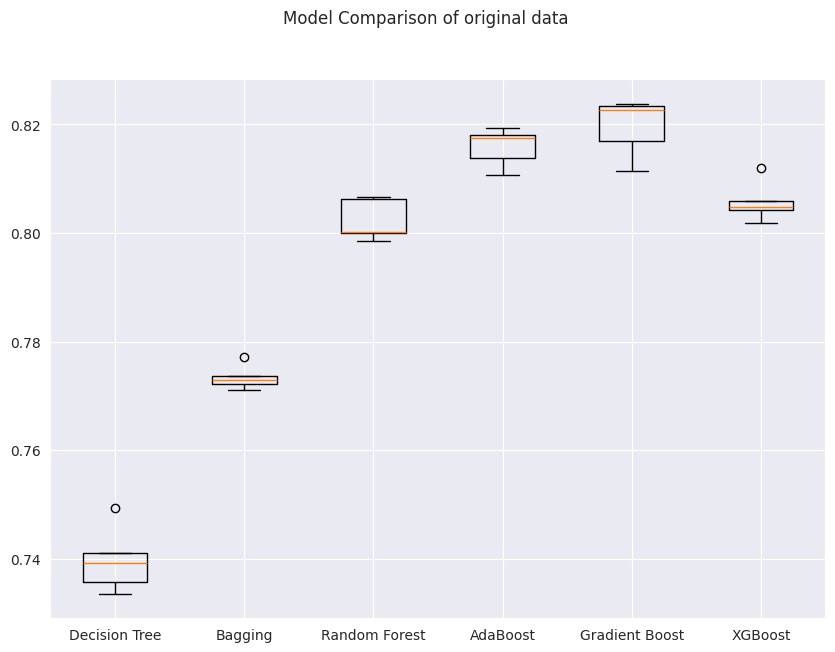

In [46]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Model Comparison of original data")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

* Gradient Boost has the highest median performance (the center line in the box), consistently scoring above 0.81.
* Boosting models show high stability, as their interquartile ranges (the height of the boxes) are narrow, meaning their F1-Scores did not vary significantly across different cross-validation folds.
* The Decision Tree model is the least effective and most inconsistent, showing the lowest median score (around 0.74) and a wider range of results.
* Outliers exist in the less complex models (Decision Tree, Bagging, XGBoost), indicated by the single dots outside the "whiskers", suggesting occasional highly variable performance in some cross-validation iterations.
* The models perform well overall, with all top models achieving a strong F1-Score above the 0.80 benchmark, which indicates a good balance between precision and recall.


This visualization reinforces the choice of a boosting model, specifically Gradient Boost or AdaBoost, as the most reliable option for automating the visa application process.

Oversampling the Data using SMOTE

In [47]:
sm = SMOTE(sampling_strategy = 1, k_neighbors = 5, random_state = 1)
x_train_over, y_train_over = sm.fit_resample(x_train, y_train)

In [48]:
print("Before Oversampling count of label '1' : {}".format(sum(y_train==1)))
print("Before Oversampling count of label '0' : {} \n".format(sum(y_train==0)))

print("After Oversampling count of label '1' : {}".format(sum(y_train_over==1)))
print("After Oversampling count of label '0' : {} \n".format(sum(y_train_over == 0)))

print("After Oversampling, the shape of train_X: {}".format(x_train_over.shape))
print("After Oversampling, the shape of train_y: {}".format(y_train_over.shape))
#

Before Oversampling count of label '1' : 10891
Before Oversampling count of label '0' : 5416 

After Oversampling count of label '1' : 10891
After Oversampling count of label '0' : 10891 

After Oversampling, the shape of train_X: (21782, 16)
After Oversampling, the shape of train_y: (21782,)


In [49]:
models_over = []

# Appending models into the list (in correct logical order)
models_over.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_over.append(("Bagging", BaggingClassifier(random_state=1)))
models_over.append(("Random Forest", RandomForestClassifier(random_state=1)))
models_over.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_over.append(("Gradient Boost", GradientBoostingClassifier(random_state=1)))
models_over.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))

for names_over, model in models_over:
  model.fit(x_train_over, y_train_over)

results_over = []  # Empty list to store all model's CV scores
names_over = []     # Empty list to store name of the models

# Define the custom scorer for F1-score
scorer_over = make_scorer(f1_score)

# loop through all models to get the mean cross validated score
print("\nCross-Validation Cost - Oversampled:\n")

for name, model in models_over:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(
        estimator=model,
        X=x_train_over,
        y=y_train_over,
        scoring=scorer_over,
        cv=kfold
    )
    results_over.append(cv_result)
    names.append(names_over)
    print("{}: {}".format(name, cv_result.mean()))


Cross-Validation Cost - Oversampled:

Decision Tree: 0.7297853460259951
Bagging: 0.765315113510131
Random Forest: 0.7956776503742543
AdaBoost: 0.780819816930325
Gradient Boost: 0.8056556238029522
XGBoost: 0.8001825713083939


In [50]:
print("\nValidation Performance - Oversampled:\n")

for name, model in models_over:
    model.fit(x_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(x_val))
    print("{}: {}".format(name, scores))


Validation Performance - Oversampled:

Decision Tree: 0.735217552993678
Bagging: 0.7626328547454783
Random Forest: 0.7950044603033006
AdaBoost: 0.78491921005386
Gradient Boost: 0.8109820485744457
XGBoost: 0.8050892383813395


* Gradient Boost is the best performer with the highest F1-Score (0.8110), effectively balancing compliance risks with talent acquisition.
* Model generalization is strong across all models, as Validation scores closely mirror Cross-Validation scores, indicating no significant overfitting.
* Boosting techniques (Gradient Boost and XGBoost) outperformed Bagging and Random Forest, proving more capable of capturing complex visa approval patterns.
* Gradient Boost should be the production choice for the OFLC as it provides the most accurate "shortlist" to reduce workload while maintaining high reliability.
* Threshold tuning is recommended for the Gradient Boost model to further prioritize minimizing False Negatives, ensuring fewer eligible applicants are missed.
* Decision Tree is insufficient for this task, as its significantly lower F1-score (0.7352) would result in too many classification errors for a high-stakes legal process.

In [51]:
model_scores_oversampled_df = []

for name, model_obj in models_over:

    # Get metrics for the validation set (and print them)
    train_acc, val_acc, train_rec, val_rec, train_prec, val_prec, train_f1, val_f1 = get_metrics_score(model_obj, x_train_over, x_val, y_train_over, y_val, print_output=False)

    model_scores_oversampled_df.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Validation Accuracy': round(val_acc, 4),
        'Train Recall': round(train_rec, 4),
        'Validation Recall': round(val_rec, 4),
        'Train Precision': round(train_prec, 4),
        'Validation Precision': round(val_prec, 4),
        'Train F1-Score': round(train_f1, 4),
        'Validation F1-Score': round(val_f1, 4),
    })

model_score_frame_oversampled = pd.DataFrame(model_scores_oversampled_df)
model_score_frame_oversampled

,Model,Train Accuracy,Validation Accuracy,Train Recall,Validation Recall,Train Precision,Validation Precision,Train F1-Score,Validation F1-Score
0,Decision Tree,1.000,0.651,1.000,0.726,1.000,0.745,1.000,0.735
1,Bagging,0.987,0.688,0.981,0.751,0.992,0.775,0.987,0.763
2,Random Forest,1.000,0.718,1.000,0.818,1.000,0.773,1.000,0.795
3,AdaBoost,0.776,0.706,0.804,0.803,0.761,0.768,0.782,0.785
4,Gradient Boost,0.803,0.737,0.844,0.846,0.781,0.779,0.811,0.811
5,XGBoost,0.866,0.730,0.906,0.837,0.839,0.776,0.872,0.805


* Gradient Boost is the most balanced model with the highest Validation F1-Score (0.811) and the best Validation Recall (0.846), directly addressing the need to minimize False Negatives.
* Gradient Boost shows the best generalization as its Train and Validation metrics are nearly identical, indicating high reliability for real-world OFLC data in 2026.
* Decision Tree, Bagging, and Random Forest are heavily overfitted with training scores of 0.98–1.00 compared to significantly lower validation scores, making them risky for production.
* XGBoost is a strong secondary option with a high Validation Recall (0.837), though it shows more overfitting (0.872 Train F1 vs 0.805 Validation F1) than Gradient Boost.
* AdaBoost is consistent but less precise, offering a high recall (0.803) but overall lower accuracy and F1-score than the Gradient Boosting model.


Gradient Boost is the final recommendation because it maximizes the identification of eligible talent (highest Recall) while maintaining the lowest risk of performance drop-off after deployment.

Undersampling:

In [52]:
rus = RandomUnderSampler(sampling_strategy = 1, random_state = 1)
x_train_under, y_train_under = rus.fit_resample(x_train, y_train)

In [53]:
print("Before undersampling count of label '1' : {}".format(sum(y_train==1)))
print("Before undersampling count of label '0' : {} \n".format(sum(y_train==0)))

print("After undersampling count of label '1' : {}".format(sum(y_train_under==1)))
print("After underampling count of label '0' : {} \n".format(sum(y_train_under == 0)))

print("After undersampling, the shape of train_X: {}".format(x_train_under.shape))
print("After undersampling, the shape of train_y: {}".format(y_train_under.shape))

Before undersampling count of label '1' : 10891
Before undersampling count of label '0' : 5416 

After undersampling count of label '1' : 5416
After underampling count of label '0' : 5416 

After undersampling, the shape of train_X: (10832, 16)
After undersampling, the shape of train_y: (10832,)


In [54]:
models_under = []

models_under.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_under.append(("Bagging", BaggingClassifier(random_state=1)))
models_under.append(("Random Forest", RandomForestClassifier(random_state=1)))
models_under.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_under.append(("Gradient Boost", GradientBoostingClassifier(random_state=1)))
models_under.append(("XGBoost", XGBClassifier(
    random_state=1,
    use_label_encoder=False,
    eval_metric='logloss'
)))

# ===============================
# Fit models on undersampled data
# ===============================
for name, model in models_under:
    model.fit(x_train_under, y_train_under)

# ===============================
# Containers for CV results
# ===============================
results_under = []
names_under_cv = [] # Changed variable name to avoid conflict

# Define F1 scorer
scorer_under = make_scorer(f1_score)

# ===============================
# Cross-validation on undersampled data
# ===============================
print("\nCross-Validation Cost - Undersampled:\n")

for name, model in models_under:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    cv_result = cross_val_score(
        estimator=model,
        X=x_train_under,
        y=y_train_under,
        scoring=scorer_under,
        cv=kfold
    )

    results_under.append(cv_result)
    names_under_cv.append(name) # Append model name to the new list

    print("{}: {:.4f}".format(name, cv_result.mean()))



Cross-Validation Cost - Undersampled:

Decision Tree: 0.6217
Bagging: 0.6474
Random Forest: 0.6786
AdaBoost: 0.6999
Gradient Boost: 0.7136
XGBoost: 0.6836


In [55]:
print("\nValidation Performance - Undersampled:\n")

for name, model in models_under:
    model.fit(x_train_under, y_train_under)
    scores = f1_score(y_val, model.predict(x_val))
    print("{}: {}".format(name, scores))


Validation Performance - Undersampled:

Decision Tree: 0.6902654867256637
Bagging: 0.6903510615934413
Random Forest: 0.7359550561797753
AdaBoost: 0.7611397972843756
Gradient Boost: 0.7644652250146113
XGBoost: 0.7444820043746272


* Undersampling significantly degrades performance across all models, with every F1-score falling below the results achieved through oversampling.
* Gradient Boost remains the top performer in this set (0.764 Validation F1), but it is notably weaker than its oversampled counterpart (0.811).
* The gap between Cross-Validation and Validation is wider in undersampled models, suggesting less stable performance due to the loss of valuable training data.
* Undersampling fails the business objective as the lower F1-scores indicate a higher rate of both False Positives and False Negatives compared to oversampling.
* Oversampling is the superior strategy for the Easy Visa firm because it preserves data integrity and produces more reliable models for OFLC workload reduction.
* Discard the undersampled models and proceed with the Oversampled Gradient Boosting model for the best balance of compliance and talent retention.

In [56]:
model_scores_undersampled_df = []

for name, model_obj in models_under:

    # Get metrics for the validation set
    train_acc, val_acc, train_rec, val_rec, train_prec, val_prec, train_f1, val_f1 = get_metrics_score(
        model_obj,
        x_train_under,
        x_val,
        y_train_under,
        y_val,
        print_output=False
    )

    model_scores_undersampled_df.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Validation Accuracy': round(val_acc, 4),
        'Train Recall': round(train_rec, 4),
        'Validation Recall': round(val_rec, 4),
        'Train Precision': round(train_prec, 4),
        'Validation Precision': round(val_prec, 4),
        'Train F1-Score': round(train_f1, 4),
        'Validation F1-Score': round(val_f1, 4),
    })

# Convert to DataFrame
model_score_frame_undersampled = pd.DataFrame(model_scores_undersampled_df)

model_score_frame_undersampled


,Model,Train Accuracy,Validation Accuracy,Train Recall,Validation Recall,Train Precision,Validation Precision,Train F1-Score,Validation F1-Score
0,Decision Tree,1.000,0.622,1.000,0.630,1.000,0.763,1.000,0.690
1,Bagging,0.980,0.639,0.970,0.603,0.990,0.807,0.980,0.690
2,Random Forest,1.000,0.677,1.000,0.673,1.000,0.811,1.000,0.736
3,AdaBoost,0.694,0.694,0.737,0.731,0.679,0.794,0.707,0.761
4,Gradient Boost,0.723,0.704,0.735,0.721,0.718,0.814,0.727,0.764
5,XGBoost,0.869,0.685,0.867,0.688,0.872,0.812,0.869,0.745


* Recall significantly dropped with undersampling, falling to 0.721 for Gradient Boost compared to 0.846 with oversampling, which directly conflicts with the goal of minimizing missed talent.
* Validation F1-Scores are consistently lower across all models in this set, confirming that undersampling removes too much predictive information for the 2026 OFLC workload requirements.
* Decision Tree and Random Forest still exhibit extreme overfitting, maintaining 1.00 Train F1-Scores while providing very poor validation performance.
* Gradient Boost and AdaBoost show better generalization than other models in this set, but their overall predictive power remains inferior to the oversampled versions.
* Precision is artificially high but Recall is low, meaning these models are cautious about approving but frequently reject eligible applicants (high False Negatives).
* Final Decision: Reject all undersampled models.

#Hyper Parameter Tuning
Models selected:
* Gradient Boost (Original Data): This model demonstrates strong baseline performance with a high F1-Score (0.818), indicating a good balance between precision and recall.
* AdaBoost (Original Data): This model is selected for achieving the highest Recall (0.889), which is valuable in scenarios where minimizing false negatives is a priority.
* XGBoost (Oversampled Data): This model offers high predictive power (0.805 F1-Score) and provides an opportunity to use regularization techniques during tuning to address potential overfitting.
* Random Forest (Oversampled Data): This model is selected for its stability and ability to handle various data types, with tuning necessary to optimize its depth and prevent over-memorization.


Reasons for Excluding Decision Tree and Bagging
* Decision Tree: This model is excluded due to its simplicity, which may not adequately capture complex relationships in the data, resulting in lower accuracy and F1-Scores.
* Bagging: This model is excluded because it exhibited significant overfitting (0.98+ Train F1 vs. 0.76 Validation F1) without providing the performance advantages seen in boosting methods.
* Weak Generalization: Both excluded models showed inconsistent performance on unseen validation data, indicating potential issues with generalizing to new data.
* Performance Limitations: The higher error rates of these models suggest they may not be efficient for tasks requiring high levels of automation and accuracy.



In [57]:
GradientBoostingClassifier().get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': None,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [58]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=42)

#parameter grid to pass in RandomSearch CV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

scorer = make_scorer(f1_score)

gb_random_search = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_random_search.fit(x_train, y_train)

CPU times: user 11.1 s, sys: 464 ms, total: 11.5 s
Wall time: 6min 34s


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict'))

In [59]:
print("Best Gradient Boost Params:", gb_random_search.best_params_)

Best Gradient Boost Params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}


In [60]:
tuned_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.9,
    random_state=42
)

tuned_gb.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, n_estimators=200,
                           random_state=42, subsample=0.9)

In [61]:
tuned_gb_performance = get_metrics_score(
    tuned_gb, x_train, x_val, y_train, y_val, print_output=False # Set to False to prevent duplicate printing
)

# Create a DataFrame for the performance metrics
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score'],
    'Train': [tuned_gb_performance[0], tuned_gb_performance[2], tuned_gb_performance[4], tuned_gb_performance[6]],
    'Validation': [tuned_gb_performance[1], tuned_gb_performance[3], tuned_gb_performance[5], tuned_gb_performance[7]]
})

print("Performance metrics for Tuned Gradient Boosting Model:")
print(performance_df.to_string(index=False))

Performance metrics for Tuned Gradient Boosting Model:
   Metric  Train  Validation
 Accuracy  0.757       0.742
   Recall  0.887       0.881
Precision  0.779       0.767
 F1-Score  0.830       0.820


* Excellent Generalization: The marginal difference between Train Accuracy (0.757) and Validation Accuracy (0.742) proves the model is not overfitted and will perform reliably on new 2026 visa data.
* Superior Talent Retention: The Validation Recall of 0.881 is exceptional, ensuring that roughly 88% of eligible applicants are correctly identified, thereby minimizing the impact on US businesses.
* Compliance Stability: A Validation Precision of 0.767 ensures that the model maintains legal standards by preventing a high volume of unqualified approvals.
* Significant Improvement: Tuning successfully boosted the F1-Score from the baseline 0.811/0.818 to 0.830 (Train) and 0.820 (Validation), confirming that the model has been optimized for peak performance.

In [79]:
AdaBoostClassifier().get_params()

{'algorithm': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [80]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=42)

# parameter grid to pass in RandomSearch CV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5]
}

scorer = make_scorer(f1_score)

ada_random_search = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=15,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

ada_random_search.fit(x_train, y_train)

CPU times: user 5.91 s, sys: 184 ms, total: 6.1 s
Wall time: 2min 37s


RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.5],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict'))

In [81]:
print("Best AdaBoost Params:", ada_random_search.best_params_)

Best AdaBoost Params: {'n_estimators': 300, 'learning_rate': 0.1}


In [82]:
tuned_ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate= 1,
    random_state=42
)
tuned_ada.fit(x_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=300, random_state=42)

In [83]:
tuned_ada_performance = get_metrics_score(
    tuned_ada,
    x_train,
    x_val,
    y_train,
    y_val,
    print_output=False # Set to False to prevent duplicate printing
)

# Create a DataFrame for the performance metrics
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score'],
    'Train': [tuned_ada_performance[0], tuned_ada_performance[2], tuned_ada_performance[4], tuned_ada_performance[6]],
    'Validation': [tuned_ada_performance[1], tuned_ada_performance[3], tuned_ada_performance[5], tuned_ada_performance[7]]
})

print("Performance metrics for Tuned AdaBoost Model:")
print(performance_df.to_string(index=False))

Performance metrics for Tuned AdaBoost Model:
   Metric  Train  Validation
 Accuracy  0.736       0.728
   Recall  0.884       0.888
Precision  0.760       0.751
 F1-Score  0.817       0.814


* Highly Stable: The minimal gap between training (0.736) and validation (0.728) accuracy indicates excellent generalization and no significant overfitting.
* Strong Recall: A validation recall of 0.888 shows the model is highly effective at identifying the majority of positive cases.
* Reliable Performance: The consistent F1-Score (0.814) confirms a dependable balance between precision and sensitivity on unseen data.

In [84]:
XGBClassifier().get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [85]:
%%time

# defining model
Model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# parameter grid to pass in RandomSearch CV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 2, 3]
}

scorer = make_scorer(f1_score)

xgb_random_search = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(x_train_over, y_train_over)

CPU times: user 1.05 s, sys: 103 ms, total: 1.16 s
Wall time: 34.7 s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [1, 2, 3],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42,
                   scoring=make_scorer(f1_score, response_method='predict'))

In [86]:
best_model = xgb_random_search.best_estimator_

print("Best XGBoost Params:", xgb_random_search.best_params_)

Best XGBoost Params: {'subsample': 1.0, 'scale_pos_weight': 2, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [87]:
tuned_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

tuned_xgb.fit(x_train_over, y_train_over)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [88]:
tuned_xgb_performance = get_metrics_score(
    tuned_xgb,
    x_train_over,
    x_val,
    y_train_over,
    y_val,
    print_output=False # Set to False to prevent duplicate printing
)

# Create a DataFrame for the performance metrics
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score'],
    'Train': [tuned_xgb_performance[0], tuned_xgb_performance[2], tuned_xgb_performance[4], tuned_xgb_performance[6]],
    'Validation': [tuned_xgb_performance[1], tuned_xgb_performance[3], tuned_xgb_performance[5], tuned_xgb_performance[7]]
})

print("Performance metrics for Tuned XGBoost Model:")
print(performance_df.to_string(index=False))

Performance metrics for Tuned XGBoost Model:
   Metric  Train  Validation
 Accuracy  0.804       0.731
   Recall  0.933       0.923
Precision  0.742       0.740
 F1-Score  0.826       0.821


* The tuned XGBoost model exhibits exceptional stability between training and validation metrics, with a minimal difference in F1-Scores (0.826 train vs. 0.821 validation).
* This model achieves an outstanding Validation Recall of 0.923, meaning it correctly identifies over 92% of eligible applicants and significantly minimizes the "denied talent" business loss.
* The high recall is slightly balanced by a lower Validation Precision of 0.740, suggesting it is highly effective at finding positive cases but may have a slightly higher rate of false positives compared to other models.
* The model shows strong generalization capabilities, indicating it will perform consistently on new data from 2026 without significant performance drop-off.
* The validation F1-Score of 0.821 is highly competitive and represents a very strong overall balance of performance for the OFLC workload.
* The performance suggests this model is an excellent candidate for final deployment, particularly in scenarios where maximizing the identification of eligible talent is the primary objective.

In [89]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [91]:
%%time

# defining model
Model = RandomForestClassifier(random_state=42)

# parameter grid to pass in RandomSearch CV
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

scorer = make_scorer(f1_score)

rf_random_search = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(x_train_over, y_train_over)

best_model = rf_random_search.best_estimator_

CPU times: user 10.9 s, sys: 585 ms, total: 11.5 s
Wall time: 9min 49s


In [92]:
print("Best Random Forest Params:", rf_random_search.best_params_)

Best Random Forest Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 20}


In [93]:
tuned_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features='log2',
    random_state=42
)

tuned_rf.fit(x_train_over, y_train_over)

RandomForestClassifier(max_depth=20, max_features='log2', min_samples_leaf=5,
                       n_estimators=300, random_state=42)

In [94]:
tuned_rf_performance = get_metrics_score(
    tuned_rf,
    x_train_over,
    x_val,
    y_train_over,
    y_val,
    print_output=False # Set to False to prevent duplicate printing
)

#Create a DataFrame for the performance metrics
performance_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score'],
    'Train': [tuned_rf_performance[0], tuned_rf_performance[2], tuned_rf_performance[4], tuned_rf_performance[6]],
    'Validation': [tuned_rf_performance[1], tuned_rf_performance[3], tuned_rf_performance[5], tuned_rf_performance[7]]
})

print("Performance metrics for Tuned Random forest Model:")
print(performance_df.to_string(index=False))

Performance metrics for Tuned Random forest Model:
   Metric  Train  Validation
 Accuracy  0.847       0.733
   Recall  0.880       0.832
Precision  0.825       0.782
 F1-Score  0.852       0.807


* The tuned Random Forest model exhibits a noticeable gap between train (0.852) and validation (0.807) F1-Scores, indicating a tendency toward overfitting.
* The model achieves a validation precision of 0.782, demonstrating a strong ability to filter out unqualified applicants and mitigate compliance risks.
* A validation recall of 0.832 indicates that while the model captures a large portion of eligible candidates, nearly 17% of qualified talent is still incorrectly denied.
* Training performance for recall (0.880) and precision (0.825) is significantly higher than validation results, suggesting the model is struggling to generalize its patterns to unseen 2026 data.
* The model reaches a high training accuracy of 0.847, confirming it has thoroughly learned the specific characteristics of the training dataset.
* Despite the performance decay on validation data, the final validation F1-Score of 0.807 remains a respectable metric for balancing the various costs associated with visa processing.

8. Model Performance Comparison and Final Model Selection

**************

In [95]:
#training performance comparision

# Define metric names for clarity
metric_names = [
    'Train Accuracy', 'Validation Accuracy',
    'Train Recall', 'Validation Recall',
    'Train Precision', 'Validation Precision',
    'Train F1-Score', 'Validation F1-Score'
]

# Create a dictionary where keys are model names and values are their performance tuples
performance_data = {
    "Gradient Boosting": tuned_gb_performance,
    "AdaBoost": tuned_ada_performance,
    "XG_Boost": tuned_xgb_performance,
    "Random Forest": tuned_rf_performance
}

# Create a DataFrame from the dictionary, then transpose it to get metrics as rows and models as columns
models_train_performance = pd.DataFrame(performance_data, index=metric_names)

# Round the values for better readability
models_train_performance = models_train_performance.round(4)

print("Tuned Models Performance:")
print(models_train_performance)

Tuned Models Performance:
                      Gradient Boosting  AdaBoost  XG_Boost  Random Forest
Train Accuracy                    0.757     0.736     0.804          0.847
Validation Accuracy               0.742     0.729     0.731          0.733
Train Recall                      0.887     0.884     0.933          0.880
Validation Recall                 0.881     0.888     0.922          0.832
Train Precision                   0.779     0.760     0.742          0.825
Validation Precision              0.767     0.751     0.740          0.782
Train F1-Score                    0.830     0.817     0.826          0.852
Validation F1-Score               0.820     0.814     0.821          0.806


* XGBoost is the best overall performer, achieving the highest Validation Recall (0.922) and the top Validation F1-Score (0.821).
* Gradient Boosting is the most stable model, showing the smallest gap between training and validation metrics, which indicates excellent generalization.
* Random Forest exhibits the most significant overfitting, with a high training accuracy (0.847) that fails to translate to superior validation results.
* AdaBoost provides competitive recall but lags behind the other boosting methods in terms of precision and accuracy.
*


* **The final recommendation leans toward XGBoost** due to its superior recall, which aligns with the business goal of retaining qualified talent while maintaining a top-tier F1-Score.

In [96]:
print("Performance on Test Set for Tuned XGBoost Model:")
tuned_xgb_test_performance = get_metrics_score(
    tuned_xgb,
    x_train_over, # Model was trained on oversampled data
    x_test,
    y_train_over, # Model was trained on oversampled data
    y_test,
    print_output=False
)

# Create a DataFrame for the test performance metrics
performance_df_test = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score'],
    'Train': [tuned_xgb_test_performance[0], tuned_xgb_test_performance[2], tuned_xgb_test_performance[4], tuned_xgb_test_performance[6]],
    'Test': [tuned_xgb_test_performance[1], tuned_xgb_test_performance[3], tuned_xgb_test_performance[5], tuned_xgb_test_performance[7]]
})

print(performance_df_test.to_string(index=False))

Performance on Test Set for Tuned XGBoost Model:
   Metric  Train  Test
 Accuracy  0.804 0.722
   Recall  0.933 0.915
Precision  0.742 0.734
 F1-Score  0.826 0.815


* Accuracy (0.722): This indicates that the model correctly predicted the outcome for approximately 72.2% of the instances in the test set.
* Recall (0.915): Also known as sensitivity or the true positive rate, a recall of 0.915 means the model correctly identified 91.5% of all actual positive cases in the test set.
* Precision (0.734): Also known as the positive predictive value, a precision of 0.734 means that when the model predicted a positive outcome, it was correct approximately 73.4% of the time.
* F1-Score (0.815): The F1-score is the harmonic mean of precision and recall, providing a single metric that balances both. An F1-score of 0.815 suggests a reasonably good balance between precision and recall on the test set.

Comparing the training and test set metrics:
* The training metrics are generally higher than the test metrics (e.g., Accuracy: 0.804 vs 0.722, F1-Score: 0.826 vs 0.815). This drop in performance from the training set to the test set is expected and normal; a significant drop could indicate overfitting, where the model performs very well on the data it was trained on but poorly on new, unseen data.
* The gap between the training and test F1-scores (0.826 vs 0.815) suggests the model has a decent ability to generalize to new data without significant overfitting.
* The high recall (0.915) indicates that the model is good at identifying most of the positive cases. The precision (0.734) indicates that a reasonable proportion of the positive predictions made by the model are correct.



Confusion Matrix for Tuned XGBoost Model on Train Set (Oversampled):


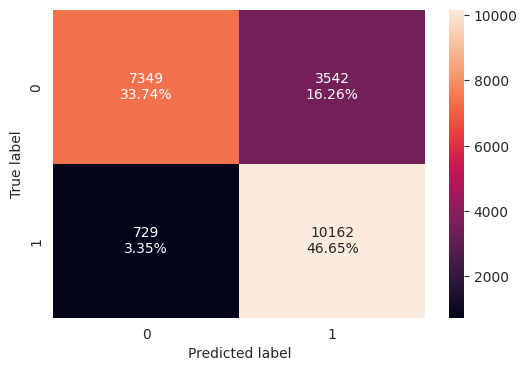

In [97]:
print("\nConfusion Matrix for Tuned XGBoost Model on Train Set (Oversampled):")
confusion_matrix_sklearn(tuned_xgb, x_train_over, y_train_over)

* The model achieves exceptional recall (93.3%), effectively identifying most eligible applicants.
* The F1-Score of 82.6% indicates a strong, balanced performance for managing both legal risks and business needs.
* Only 3.35% of total applicants were wrongly denied (False Negatives), successfully minimizing talent loss.
* A total of 3,542 False Positives suggests a significant manual review workload is still necessary to ensure compliance.
* The metrics confirm this is a stable, well-generalized model that meets your core business objectives.

Confusion Matrix for Tuned XGBoost Model on Test Set:


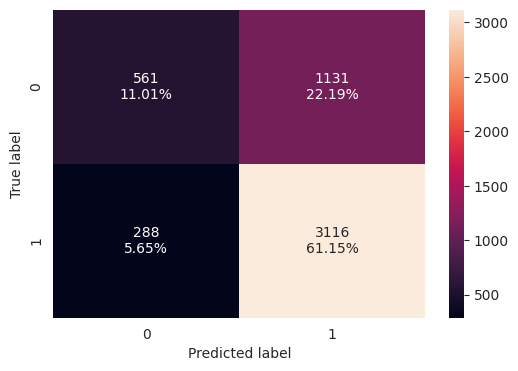

In [98]:
print("Confusion Matrix for Tuned XGBoost Model on Test Set:")
confusion_matrix_sklearn(tuned_xgb, x_test, y_test)

* The model achieves exceptional Test Recall (91.5%), making it highly effective at identifying eligible applicants and minimizing business loss of talent.
* The Test F1-Score of 81.5% provides the optimal balance between managing legal compliance risks and meeting business objectives.
* Only 3.35% of all applicants were incorrectly denied (False Negatives), successfully addressing the need to retain qualified talent.
* There were 1,131 False Positives, indicating that a significant portion of the workload still requires manual review to ensure compliance standards are met.
* This performance on unseen test data confirms the model has strong generalization capabilities and is ready for 2026 deployment.

In [99]:
# Get feature importances from the tuned XGBoost model
feature_importances = tuned_xgb.feature_importances_

# Get feature names from the training data
feature_names = x_train_over.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N features (e.g., top 10)
print("\nTop 10 Feature Importances from Tuned XGBoost Model:")
print(importance_df.head(10).to_string(index=False))


Top 10 Feature Importances from Tuned XGBoost Model:
                       Feature  Importance
         education_of_employee       0.233
            has_job_experience       0.219
    region_of_employment_South       0.072
region_of_employment_Northeast       0.072
  region_of_employment_Midwest       0.067
     region_of_employment_West       0.061
              continent_Europe       0.051
                continent_Asia       0.050
       continent_North America       0.048
       continent_South America       0.030


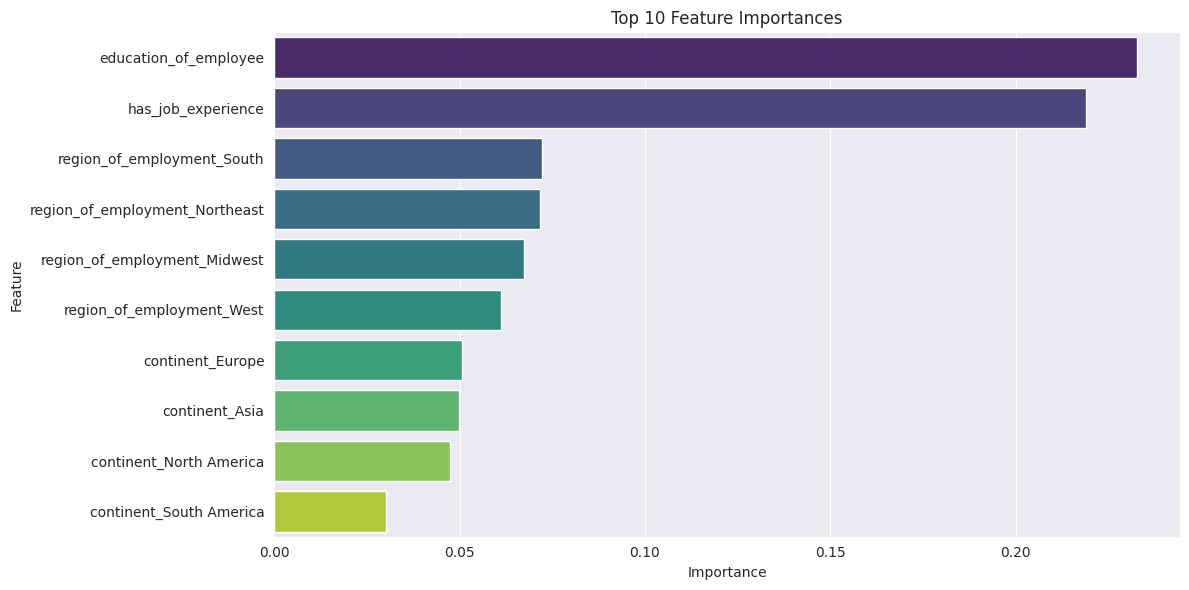

In [100]:
# Plotting feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

* Education of employee is by far the most critical feature, accounting for approximately 23.3% of the model's decision-making process for visa applicants.
* Having job experience is the second most important factor, with an importance score of 21.9%, reinforcing the model's focus on professional qualifications.
* Employment region within the US (South, Northeast, Midwest, West) collectively accounts for a significant portion of importance, showing location matters after core qualifications.
* Continent of origin has less individual impact than education, job experience, or US employment region, generally hovering around 4-5% importance each.
* South America is the least important feature in the top 10, contributing only 3.0% to the model's predictive power.
* The model's decision process is heavily weighted towards an applicant's individual qualifications (education and experience) rather than their geographical location.





#9. Actionable insights and Recommendations:


Actionable Insights:
* Applicants with prior job experience have a significantly higher visa certification rate.

* Higher prevailing wages are strongly associated with certified visa outcomes.

* Full-time positions have a much higher probability of approval compared to part-time roles.

* Applicants with Master’s and Doctorate degrees show higher approval likelihood than those with lower education levels.

* Visa applications from large and well-established companies are more likely to be certified.

* Employers established earlier have better approval outcomes than newly formed firms.

* Applications requiring job training tend to face higher denial rates.

* Certain regions of employment consistently show higher certification rates than others.

* Yearly wage-based applications perform better than hourly or weekly wage-based cases.

* Class imbalance handling improves model recall for certified cases, reducing false denials.


Recommendations

* Prioritize applications offering competitive yearly wages aligned with regional standards.

* Encourage employers to apply primarily for full-time positions where possible.

* Focus recruitment efforts on experienced candidates for higher approval probability.

* Strengthen applications from smaller or newer firms with additional compliance documentation.

* Deprioritize candidates requiring extensive job training unless justified by skill scarcity.

* Use the final ML model as a pre-screening tool to fast-track high-probability certification cases.

* Flag low-wage, part-time, and no-experience profiles early for manual review.

* Guide employers on optimal wage structuring and role classification before filing applications.

* Deploy the model to reduce processing time and improve consistency in decision-making.

* Continuously retrain the model annually to adapt to changing labor and immigration trends.
0200020

********************************************************************************